# Phase 3: Recommendation System

In this notebook, you will:
1. Build a content-based filtering system using property features
2. Implement collaborative filtering (user-based and item-based)
3. Create a hybrid recommendation system
4. Evaluate recommendation quality

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.recommendation import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Properties: {X_scaled.shape[0]}, Features: {X_scaled.shape[1]}")

Properties: 20640, Features: 8


## 2. Content-Based Filtering

Similarity matrix shape: (500, 500)
Value range: [-0.4519, 1.0000]

Top-5 content-based recommendations for property #42:
  Property   81  —  similarity: 0.9938
  Property   71  —  similarity: 0.9933
  Property   35  —  similarity: 0.9915
  Property   55  —  similarity: 0.9910
  Property   66  —  similarity: 0.9910


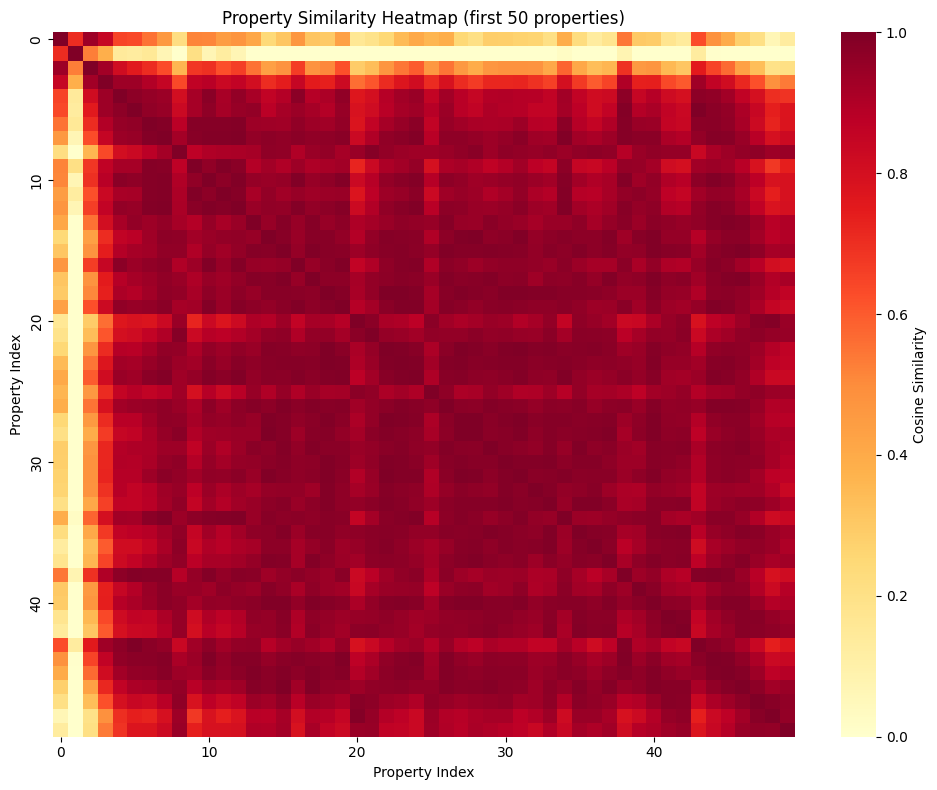

In [3]:

# Compute similarity matrix on a manageable subset
SUBSET_SIZE = 500
SAMPLE_PROPERTY = 42

X_subset = X_scaled[:SUBSET_SIZE]
similarity_matrix = compute_property_similarity(X_subset, metric='cosine')
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Value range: [{similarity_matrix.min():.4f}, {similarity_matrix.max():.4f}]")

# Get content-based recommendations for a sample property
recs = content_based_recommend(SAMPLE_PROPERTY, similarity_matrix, n_recommendations=5)
print(f"\nTop-5 content-based recommendations for property #{SAMPLE_PROPERTY}:")
for r in recs:
    print(f"  Property {r['property_index']:>4d}  —  similarity: {r['similarity_score']:.4f}")

# Visualize similarity heatmap (first 50 properties for clarity)
HEATMAP_SIZE = 50
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    similarity_matrix[:HEATMAP_SIZE, :HEATMAP_SIZE],
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1,
    xticklabels=10,
    yticklabels=10,
    cbar_kws={'label': 'Cosine Similarity'},
)
ax.set_title(f'Property Similarity Heatmap (first {HEATMAP_SIZE} properties)')
ax.set_xlabel('Property Index')
ax.set_ylabel('Property Index')
plt.tight_layout()
plt.show()


In [4]:

# KNN-based recommendations for the same sample property
knn_recs = knn_recommend(X_subset, SAMPLE_PROPERTY, n_recommendations=5, metric='minkowski')

print(f"KNN recommendations for property #{SAMPLE_PROPERTY}:")
for r in knn_recs:
    print(f"  Property {r['property_index']:>4d}  —  distance: {r['distance']:.4f}")

# --- Side-by-side comparison ---
cosine_indices = {r['property_index'] for r in recs}
knn_indices     = {r['property_index'] for r in knn_recs}
overlap         = cosine_indices & knn_indices

print(f"\n{'Property':<12} {'Cosine Sim':>12} {'KNN Dist':>10} {'In Both?':>10}")
print("-" * 48)

# Build lookup dicts for clean display
cosine_lookup = {r['property_index']: r['similarity_score'] for r in recs}
knn_lookup    = {r['property_index']: r['distance']         for r in knn_recs}

all_indices = sorted(cosine_indices | knn_indices)
for idx in all_indices:
    cos_val = f"{cosine_lookup[idx]:.4f}" if idx in cosine_lookup else "—"
    knn_val = f"{knn_lookup[idx]:.4f}"   if idx in knn_lookup    else "—"
    tag     = "✓" if idx in overlap else ""
    print(f"  {idx:<10} {cos_val:>12} {knn_val:>10} {tag:>10}")

print(f"\nOverlap: {len(overlap)}/5 properties appear in both recommendation lists")


KNN recommendations for property #42:
  Property   71  —  distance: 0.3460
  Property   81  —  distance: 0.3883
  Property   55  —  distance: 0.3989
  Property   66  —  distance: 0.4050
  Property   35  —  distance: 0.4258

Property       Cosine Sim   KNN Dist   In Both?
------------------------------------------------
  35               0.9915     0.4258          ✓
  55               0.9910     0.3989          ✓
  66               0.9910     0.4050          ✓
  71               0.9933     0.3460          ✓
  81               0.9938     0.3883          ✓

Overlap: 5/5 properties appear in both recommendation lists


## 3. Collaborative Filtering

Matrix shape:     (100, 500)
Actual sparsity:  95.0%
Rated entries:    2,487
Rating range:     1 – 5


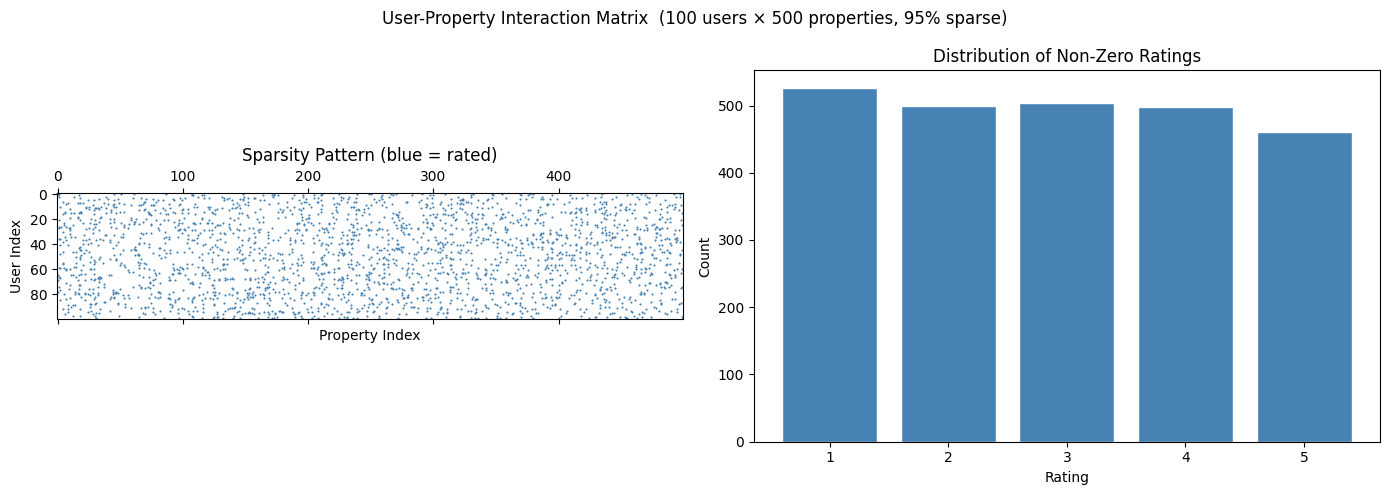

In [5]:

# Create user-property interaction matrix
N_USERS = 100
N_PROPERTIES = 500
SPARSITY = 0.95

user_property_matrix = create_user_property_matrix(
    n_users=N_USERS, n_properties=N_PROPERTIES, sparsity=SPARSITY, random_state=42
)

actual_sparsity = (user_property_matrix == 0).sum() / user_property_matrix.size
print(f"Matrix shape:     {user_property_matrix.shape}")
print(f"Actual sparsity:  {actual_sparsity:.1%}")
print(f"Rated entries:    {(user_property_matrix > 0).sum():,}")
print(f"Rating range:     {user_property_matrix[user_property_matrix > 0].min()} – {user_property_matrix.max()}")

# Visualize sparsity pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binary sparsity map
axes[0].spy(user_property_matrix, markersize=0.5, color='steelblue')
axes[0].set_title('Sparsity Pattern (blue = rated)')
axes[0].set_xlabel('Property Index')
axes[0].set_ylabel('User Index')

# Right: rating distribution (excluding zeros)
rated_values = user_property_matrix[user_property_matrix > 0]
axes[1].hist(rated_values, bins=5, range=(0.5, 5.5), color='steelblue', edgecolor='white', rwidth=0.8)
axes[1].set_title('Distribution of Non-Zero Ratings')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle(f'User-Property Interaction Matrix  ({N_USERS} users × {N_PROPERTIES} properties, {actual_sparsity:.0%} sparse)')
plt.tight_layout()
plt.show()


In [ ]:
# TODO: User-based collaborative filtering
# Get recommendations for sample users

In [ ]:
# TODO: Item-based collaborative filtering
# Compare with user-based results

## 4. Hybrid Recommendation System

In [ ]:
# TODO: Build hybrid recommender
# Experiment with different content_weight / collaborative_weight

## 5. Evaluation

In [ ]:
# TODO: Evaluate each recommendation approach
# Compare precision/recall across methods

## Summary

TODO: Write a summary:
- Which approach produced the most relevant recommendations?
- How did the hybrid system compare to individual approaches?
- What are the limitations of each method for real estate?